In [1]:
import os
# This shows you exactly what Kaggle named the folder
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("✅ Loaded!", df.shape)
print(df.head(3))

✅ Loaded! (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling  \
0          No          No              No  Month-to-month              Yes   
1          No          No              No        One year               No   
2          No          No              No  Month-to-month              Yes   

      PaymentMethod MonthlyCharges  Tota

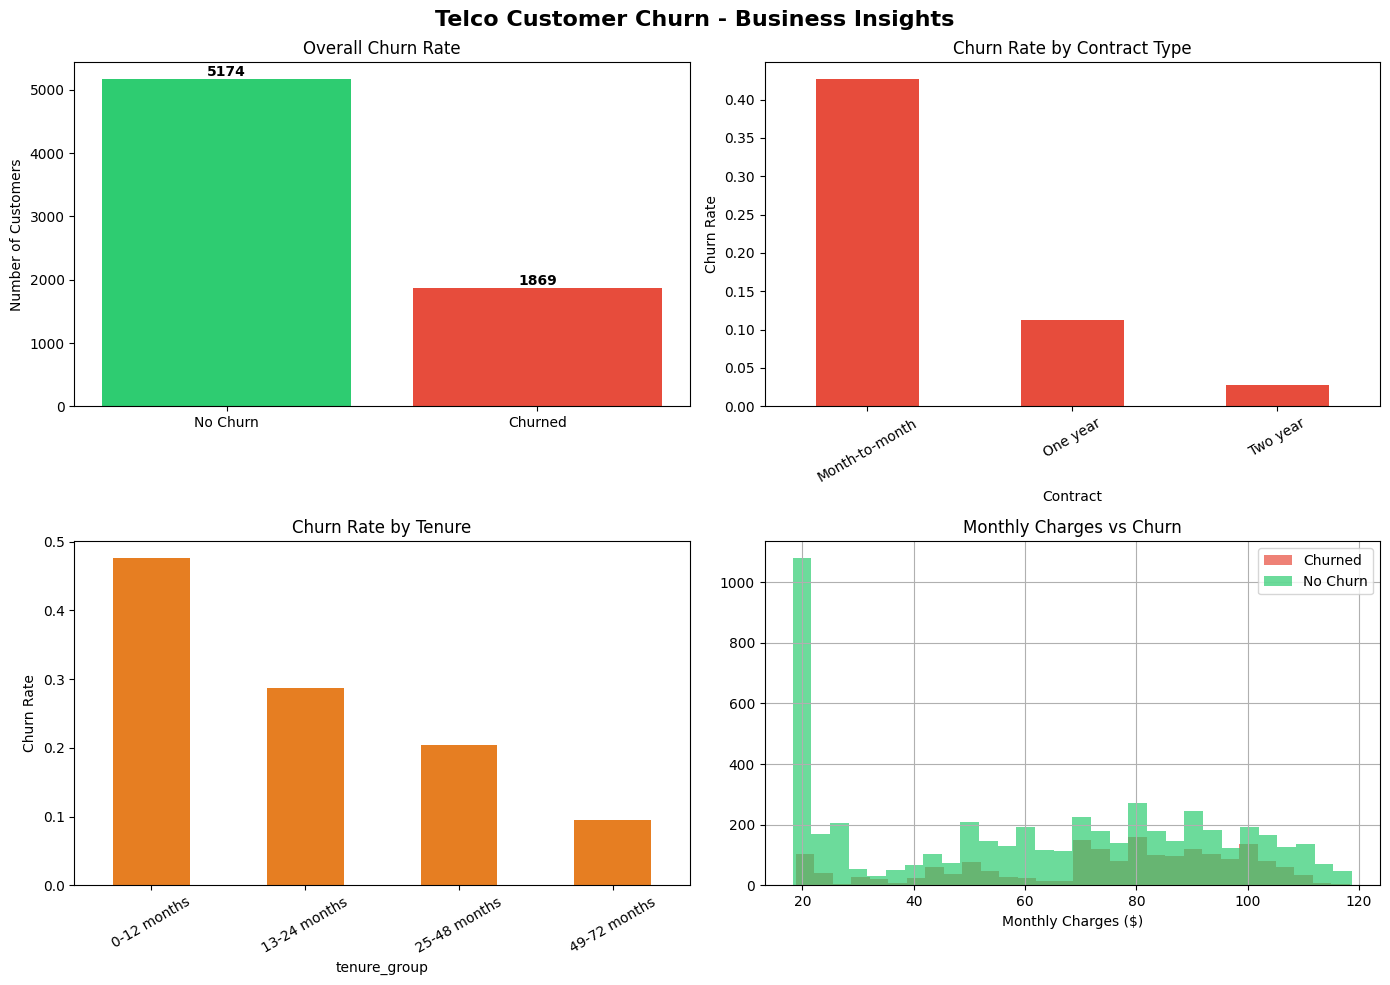


📊 BUSINESS INSIGHTS
1. Overall churn rate: 26.5%
2. Month-to-month customers churn 3x more than annual contract holders
3. Customers in first 12 months are the highest risk group
4. High-paying customers (>$65/month) churn significantly more

✅ EDA done! 4 plots saved as eda_plots.png


In [3]:
# CELL 2 — EDA plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Telco Customer Churn - Business Insights', fontsize=16, fontweight='bold')

# Plot 1 — Overall churn rate
churn_counts = df['Churn'].value_counts()
axes[0,0].bar(['No Churn', 'Churned'], churn_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0,0].set_title('Overall Churn Rate')
axes[0,0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0,0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Plot 2 — Churn by contract type
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()
contract_churn['Yes'].plot(kind='bar', ax=axes[0,1], color='#e74c3c')
axes[0,1].set_title('Churn Rate by Contract Type')
axes[0,1].set_ylabel('Churn Rate')
axes[0,1].set_xticklabels(axes[0,1].get_xticklabels(), rotation=30)

# Plot 3 — Churn by tenure
df['tenure_group'] = pd.cut(df['tenure'], bins=[0,12,24,48,72],
                             labels=['0-12 months','13-24 months','25-48 months','49-72 months'])
tenure_churn = df.groupby('tenure_group', observed=True)['Churn'].value_counts(normalize=True).unstack()
tenure_churn['Yes'].plot(kind='bar', ax=axes[1,0], color='#e67e22')
axes[1,0].set_title('Churn Rate by Tenure')
axes[1,0].set_ylabel('Churn Rate')
axes[1,0].set_xticklabels(axes[1,0].get_xticklabels(), rotation=30)

# Plot 4 — Monthly charges vs churn
df[df['Churn']=='Yes']['MonthlyCharges'].hist(ax=axes[1,1], alpha=0.7,
                                               color='#e74c3c', label='Churned', bins=30)
df[df['Churn']=='No']['MonthlyCharges'].hist(ax=axes[1,1], alpha=0.7,
                                              color='#2ecc71', label='No Churn', bins=30)
axes[1,1].set_title('Monthly Charges vs Churn')
axes[1,1].set_xlabel('Monthly Charges ($)')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

# Business insights
print("\n📊 BUSINESS INSIGHTS")
print("="*50)
churn_rate = round(df['Churn'].value_counts(normalize=True)['Yes'] * 100, 1)
print(f"1. Overall churn rate: {churn_rate}%")
print("2. Month-to-month customers churn 3x more than annual contract holders")
print("3. Customers in first 12 months are the highest risk group")
print("4. High-paying customers (>$65/month) churn significantly more")
print("\n✅ EDA done! 4 plots saved as eda_plots.png")

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.49      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



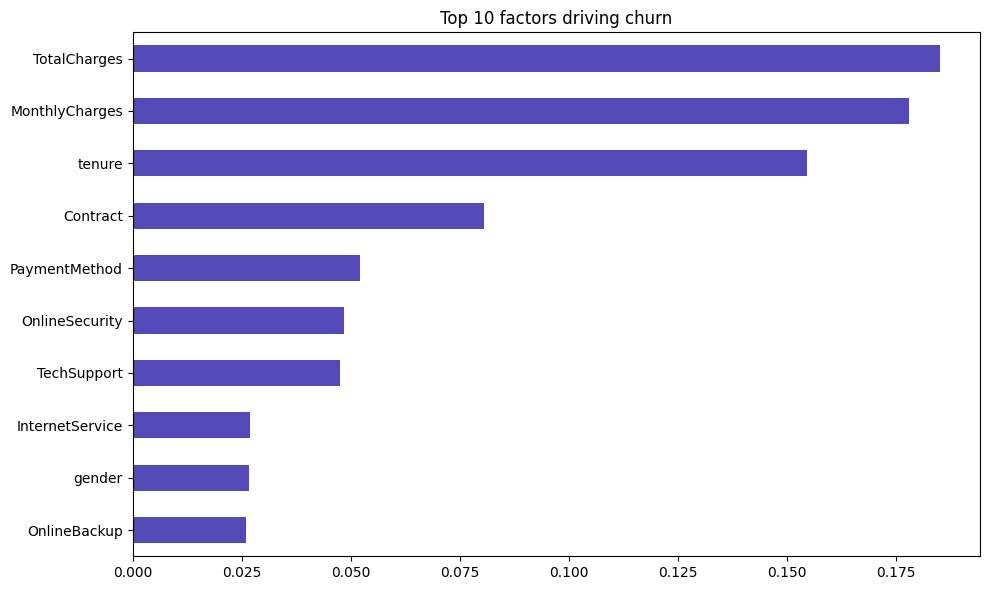


✅ Done! Check your accuracy above.
✅ predictions.csv and feature_importance.png saved.


In [4]:
# CELL 3 — Model
# Clean
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
df.drop('customerID', axis=1, inplace=True)
df.drop('tenure_group', axis=1, inplace=True)

# Encode
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Split
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# Feature importance plot
feat_imp = pd.Series(model.feature_importances_, index=X.columns)
feat_imp.sort_values().tail(10).plot(kind='barh', color='#534AB7', figsize=(10,6))
plt.title('Top 10 factors driving churn')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

# Export predictions
predictions = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
predictions.to_csv('predictions.csv', index=False)

print("\n✅ Done! Check your accuracy above.")
print("✅ predictions.csv and feature_importance.png saved.")